# Formative Assignment: Advanced Linear Algebra (PCA)

This notebook implements Principal Component Analysis (PCA) on the **Africa Malaria Dataset**.

**Constraints respected:**
1. Outputs displayed for every code cell
2. Code is split across separate cells — one step per cell
3. Only `numpy` and `matplotlib` are used (no sklearn, pandas, or other libraries)


## Step 1: Load and Standardize the Data

Standardization formula: **z = (x − μ) / σ** — shifts each feature to mean 0 and scales to standard deviation 1.

In [ ]:
import numpy as np

In [2]:
with open('DatasetAfricaMalaria.csv', 'r') as f:
    raw_lines = f.read().splitlines()

def clean_line(line):
    cleaned, in_quotes = [], False
    for ch in line:
        if ch == '"':
            in_quotes = not in_quotes
        elif ch == ',' and in_quotes:
            cleaned.append(';')
        else:
            cleaned.append(ch)
    return ''.join(cleaned)


In [3]:
table  = np.genfromtxt([clean_line(line) for line in raw_lines], delimiter=',', dtype=str, encoding=None)
header = table[0]
rows   = table[1:]
rows

array([['Algeria', '2007', 'DZA', ..., '28.033886', '1.659626',
        'POINT (28.033886 1.659626)'],
       ['Angola', '2007', 'AGO', ..., '-11.202692', '17.873887',
        'POINT (-11.202692 17.873887)'],
       ['Benin', '2007', 'BEN', ..., '9.30769', '2.315834',
        'POINT (9.307689999999999 2.315834)'],
       ...,
       ['Uganda', '2017', 'UGA', ..., '1.373333', '32.290275',
        'POINT (1.373333 32.290275)'],
       ['Zambia', '2017', 'ZMB', ..., '-13.133897', '27.849332',
        'POINT (-13.133897 27.849332)'],
       ['Zimbabwe', '2017', 'ZWE', ..., '-19.015438', '29.154857',
        'POINT (-19.015438 29.154857)']], dtype='<U87')

In [ ]:
# Numeric feature columns only and skip non-numeric metadata
feature_names = np.char.replace(header[3:24], ';', ',')   # restore commas for display
raw_data = np.array([
    [float(v) if v.strip() != '' else np.nan for v in row[3:24]]
    for row in rows
])

raw_data

array([[1.0000000e-02, 2.6000000e+01,           nan, ..., 8.5850000e+01,
        7.6940000e+01, 9.0570000e+01],
       [2.8672000e+02, 1.5334850e+06, 1.8000000e+01, ..., 3.7260000e+01,
        1.4000000e+01, 5.4440000e+01],
       [4.8024000e+02, 0.0000000e+00,           nan, ..., 1.1800000e+01,
        4.2900000e+00, 2.2360000e+01],
       ...,
       [3.3676000e+02, 1.1667831e+07,           nan, ..., 1.8470000e+01,
        1.6170000e+01, 2.6110000e+01],
       [1.6005000e+02, 5.5056390e+06,           nan, ..., 2.6370000e+01,
        1.8930000e+01, 3.6240000e+01],
       [1.0855000e+02, 4.6750800e+05,           nan, ..., 3.6220000e+01,
        3.1470000e+01, 4.6220000e+01]])

In [5]:
# Keep only columns where at least 50% of rows have a value
col_mask = np.sum(~np.isnan(raw_data), axis=0) > (raw_data.shape[0] * 0.5)
data = raw_data[:, col_mask]

# Drop any row that still contains NaN
row_mask = ~np.any(np.isnan(data), axis=1)
data = data[row_mask]

print(f"Clean data shape: {data.shape}  ({data.shape[0]} samples, {data.shape[1]} features)")

Clean data shape: (528, 12)  (528 samples, 12 features)


In [ ]:
# Standardization: z = (x - mu) / sigma
mean = np.mean(data, axis=0)
std  = np.std(data, axis=0)
std[std == 0] = 1

standardized_data = (data - mean) / std  

standardized_data[:5]

array([[-1.19922544, -0.49862971, -1.30790788, -1.84126952,  1.30787926,
        -0.78941194,  1.78442393,  2.06199833,  1.25604516,  2.3068026 ,
         2.3453371 ,  2.18520393],
       [ 0.56315816,  0.19028066, -0.8636883 ,  0.36055827,  0.86365444,
         0.97979387, -0.99218058, -1.49281103, -1.95720117,  0.0932321 ,
        -0.54599783,  0.38931907],
       [ 1.75271024, -0.49864139,  0.04177076,  0.43073605, -0.04181531,
         0.27211155,  0.01252855,  0.29146727, -0.80176441, -1.06662601,
        -0.99205538, -1.20525569],
       [-1.19295558, -0.49846618, -0.88694884, -2.57813619,  0.88691525,
         0.81825769,  0.97214644,  0.44497821,  1.20831818,  1.20206737,
         0.64792963,  1.52560271],
       [ 1.89753169, -0.47876376,  1.09473569,  0.57986383, -1.09479266,
         1.6720918 , -0.71845768, -0.26930591, -0.81175377, -0.89351286,
        -0.89604506, -0.00584519]])

## Step 3: Calculate the Covariance Matrix

The covariance matrix captures how every pair of features varies together and is the mathematical foundation of PCA.

In [ ]:
n = standardized_data.shape[0]

# C = (1 / (n-1)) * X^T . X   — X is already mean-centred after standardisation
cov_matrix = (1 / (n - 1)) * (standardized_data.T @ standardized_data)  # Calculate covariance matrix

print(f"Covariance matrix shape: {cov_matrix.shape}")
cov_matrix

Covariance matrix shape: (12, 12)


array([[ 1.00189753,  0.28093302,  0.21595252,  0.39697941, -0.21595715,
         0.32418282, -0.39626361, -0.36983187, -0.42716034, -0.50945897,
        -0.44601937, -0.49857409],
       [ 0.28093302,  1.00189753,  0.21504725,  0.26082641, -0.21505665,
         0.28330172, -0.25323919, -0.20778335, -0.17557612, -0.19693324,
        -0.13397722, -0.23930845],
       [ 0.21595252,  0.21504725,  1.00189753,  0.68328793, -1.00189752,
         0.16210634, -0.63194793, -0.29482915, -0.27216502, -0.47961245,
        -0.27591691, -0.45762836],
       [ 0.39697941,  0.26082641,  0.68328793,  1.00189753, -0.6832909 ,
         0.1723354 , -0.57523929, -0.39109312, -0.38158943, -0.48984843,
        -0.37036182, -0.4641653 ],
       [-0.21595715, -0.21505665, -1.00189752, -0.6832909 ,  1.00189753,
        -0.16211233,  0.63195026,  0.29483063,  0.2721706 ,  0.47961455,
         0.27591921,  0.45762996],
       [ 0.32418282,  0.28330172,  0.16210634,  0.1723354 , -0.16211233,
         1.00189753, -

### Why do we compute a covariance matrix? 

The covariance matrix quantifies how strongly every pair of features moves together, exposing linear dependencies in the data.
**Reason 1:** Its eigenvectors point in the directions of maximum variance — these become the principal components that PCA projects onto, so without the covariance matrix we cannot determine those directions.
**Reason 2:** It reveals redundancy — features with high covariance (e.g. rural sanitation and malaria incidence) carry overlapping information, so projecting onto their shared principal component compresses them into fewer dimensions without major information loss.
Together these two properties let PCA replace many correlated features with a small set of uncorrelated components that still explain most of the total variance in the dataset.


## Step 4: Perform Eigendecomposition

Eigendecomposition finds the **directions** (eigenvectors) and **magnitudes** (eigenvalues) of maximum variance inside the covariance matrix.

In [14]:
eigenvalues  = eigenvalues.real
eigenvectors = eigenvectors.real

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors (each column = one eigenvector), shape:", eigenvectors.shape)
eigenvalues, eigenvectors

Eigenvalues:
[6.12702427e+00 1.72633085e+00 1.08446406e+00 9.61833670e-01
 7.11348152e-01 6.20998652e-01 3.53211385e-01 2.65349206e-01
 1.52476827e-01 7.86306933e-03 1.18702553e-02 1.13969171e-08]

Eigenvectors (each column = one eigenvector), shape: (12, 12)


(array([6.12702427e+00, 1.72633085e+00, 1.08446406e+00, 9.61833670e-01,
        7.11348152e-01, 6.20998652e-01, 3.53211385e-01, 2.65349206e-01,
        1.52476827e-01, 7.86306933e-03, 1.18702553e-02, 1.13969171e-08]),
 array([[-2.35854373e-01,  1.67704405e-01,  2.69011635e-01,
          3.03466736e-01, -5.15183460e-01, -5.79446271e-01,
          3.16854587e-01, -2.13634617e-01,  6.12945777e-02,
         -2.82412932e-02,  5.04720056e-03,  2.70886361e-07],
        [-1.39219310e-01, -4.86818734e-02,  7.61317085e-01,
          8.56278802e-02, -1.63670135e-01,  5.99830077e-01,
          3.04736086e-02,  2.33598544e-02,  5.60077663e-02,
          1.04021400e-02, -2.96457034e-03,  6.22941225e-06],
        [-2.71845942e-01, -5.41664585e-01, -4.34384296e-02,
         -6.83948822e-03,  1.33945797e-01, -3.79587072e-02,
          2.65244991e-01,  1.09353002e-02,  1.03150547e-01,
          4.87775787e-02,  1.67015017e-01,  7.07103568e-01],
        [-2.79049397e-01, -3.43145091e-01,  4.54860296e-02,

## Step 5: Sort Principal Components

Sort eigenvectors by their eigenvalues in **descending order** — the higher the eigenvalue, the more variance that component explains, and therefore the more important it is.

In [ ]:
sorted_indices      = np.argsort(eigenvalues)[::-1]         # Sort eigenvalues in descending order
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]       # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-2.35854373e-01,  1.67704405e-01,  2.69011635e-01,
         3.03466736e-01, -5.15183460e-01, -5.79446271e-01,
         3.16854587e-01, -2.13634617e-01,  6.12945777e-02,
         5.04720056e-03, -2.82412932e-02,  2.70886361e-07],
       [-1.39219310e-01, -4.86818734e-02,  7.61317085e-01,
         8.56278802e-02, -1.63670135e-01,  5.99830077e-01,
         3.04736086e-02,  2.33598544e-02,  5.60077663e-02,
        -2.96457034e-03,  1.04021400e-02,  6.22941225e-06],
       [-2.71845942e-01, -5.41664585e-01, -4.34384296e-02,
        -6.83948822e-03,  1.33945797e-01, -3.79587072e-02,
         2.65244991e-01,  1.09353002e-02,  1.03150547e-01,
         1.67015017e-01,  4.87775787e-02,  7.07103568e-01],
       [-2.79049397e-01, -3.43145091e-01,  4.54860296e-02,
         2.77774284e-02, -2.77217294e-01, -1.85951738e-01,
        -8.25503808e-01,  6.95168325e-02, -5.13541751e-02,
        -3.34817348e-02, -8.21182262e-03,  2.43138253e-06],
       [ 2.71847468e-01,  5.41662678e-01,  4.3429603

In [10]:
# Explained variance ratio and cumulative sum
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

print("Explained variance per component:")
for i, (ev, cu) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1:>2}: {ev*100:6.2f}%   Cumulative: {cu*100:6.2f}%")

print("\nSorted eigenvectors (columns are principal components):")
sorted_eigenvectors

Explained variance per component:
  PC 1:  50.96%   Cumulative:  50.96%
  PC 2:  14.36%   Cumulative:  65.32%
  PC 3:   9.02%   Cumulative:  74.34%
  PC 4:   8.00%   Cumulative:  82.34%
  PC 5:   5.92%   Cumulative:  88.26%
  PC 6:   5.17%   Cumulative:  93.42%
  PC 7:   2.94%   Cumulative:  96.36%
  PC 8:   2.21%   Cumulative:  98.57%
  PC 9:   1.27%   Cumulative:  99.84%
  PC10:   0.10%   Cumulative:  99.93%
  PC11:   0.07%   Cumulative: 100.00%
  PC12:   0.00%   Cumulative: 100.00%

Sorted eigenvectors (columns are principal components):


array([[-2.35854373e-01,  1.67704405e-01,  2.69011635e-01,
         3.03466736e-01, -5.15183460e-01, -5.79446271e-01,
         3.16854587e-01, -2.13634617e-01,  6.12945777e-02,
         5.04720056e-03, -2.82412932e-02,  2.70886361e-07],
       [-1.39219310e-01, -4.86818734e-02,  7.61317085e-01,
         8.56278802e-02, -1.63670135e-01,  5.99830077e-01,
         3.04736086e-02,  2.33598544e-02,  5.60077663e-02,
        -2.96457034e-03,  1.04021400e-02,  6.22941225e-06],
       [-2.71845942e-01, -5.41664585e-01, -4.34384296e-02,
        -6.83948822e-03,  1.33945797e-01, -3.79587072e-02,
         2.65244991e-01,  1.09353002e-02,  1.03150547e-01,
         1.67015017e-01,  4.87775787e-02,  7.07103568e-01],
       [-2.79049397e-01, -3.43145091e-01,  4.54860296e-02,
         2.77774284e-02, -2.77217294e-01, -1.85951738e-01,
        -8.25503808e-01,  6.95168325e-02, -5.13541751e-02,
        -3.34817348e-02, -8.21182262e-03,  2.43138253e-06],
       [ 2.71847468e-01,  5.41662678e-01,  4.3429603

### How is Explained Variance used in PCA?

Explained variance ratio tells us what fraction of the total data spread each principal component accounts for.
We sort components from highest to lowest eigenvalue, then compute the **cumulative** explained variance and keep only the minimum number of components needed to exceed a chosen threshold (typically 90–95%).
Components below the threshold contribute mostly noise and can be safely discarded, while those above it capture the essential structure of the dataset — guiding the choice of how many dimensions to retain without significant information loss.


## Step 6: Project Data onto Principal Components

Select the top-*k* eigenvectors and project the standardised data onto them to obtain the lower-dimensional representation.

In [ ]:
# Select the fewest components whose cumulative explained variance reaches >= 90 %
num_components = int(np.argmax(cumulative_variance >= 0.90)) + 1  # Decide on the number of principal components to keep
print(f"Components chosen to reach >=90% cumulative variance: {num_components}")
print(f"Variance retained: {cumulative_variance[num_components - 1] * 100:.2f}%")

# Build projection matrix W of shape (p, k)
W = sorted_eigenvectors[:, :num_components]

# Project: reduced_data = X_standardised . W   →  shape (n, k)
reduced_data = standardized_data @ W               # Project data onto the principal components

reduced_data[:5]

Components chosen to reach >=90% cumulative variance: 6
Variance retained: 93.42%


array([[ 5.71056713, -0.29446529,  0.55606756, -0.46675088,  0.020904  ,
        -0.20034158],
       [-1.39062768,  1.97949505,  0.53343327, -1.82331748, -0.56090597,
        -0.42547373],
       [-1.78336707,  0.87045716, -0.41557233,  1.37285094, -0.63284653,
        -1.04344306],
       [ 3.39871455,  0.94344196,  0.37567624, -0.59289377,  1.71598515,
         0.02198184],
       [-2.65056382, -0.06697604,  0.33887315,  0.20181066,  0.31544325,
        -1.91743433]])

## Step 7: Output the Reduced Data

In [ ]:
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]                                     # Display the first few rows of reduced data

Reduced Data Shape: (528, 6)


array([[ 5.71056713, -0.29446529,  0.55606756, -0.46675088,  0.020904  ,
        -0.20034158],
       [-1.39062768,  1.97949505,  0.53343327, -1.82331748, -0.56090597,
        -0.42547373],
       [-1.78336707,  0.87045716, -0.41557233,  1.37285094, -0.63284653,
        -1.04344306],
       [ 3.39871455,  0.94344196,  0.37567624, -0.59289377,  1.71598515,
         0.02198184],
       [-2.65056382, -0.06697604,  0.33887315,  0.20181066,  0.31544325,
        -1.91743433]])

## Step 8: Visualize Before and After PCA

Side-by-side scatter plots comparing the original standardised feature space against the PCA-reduced space.

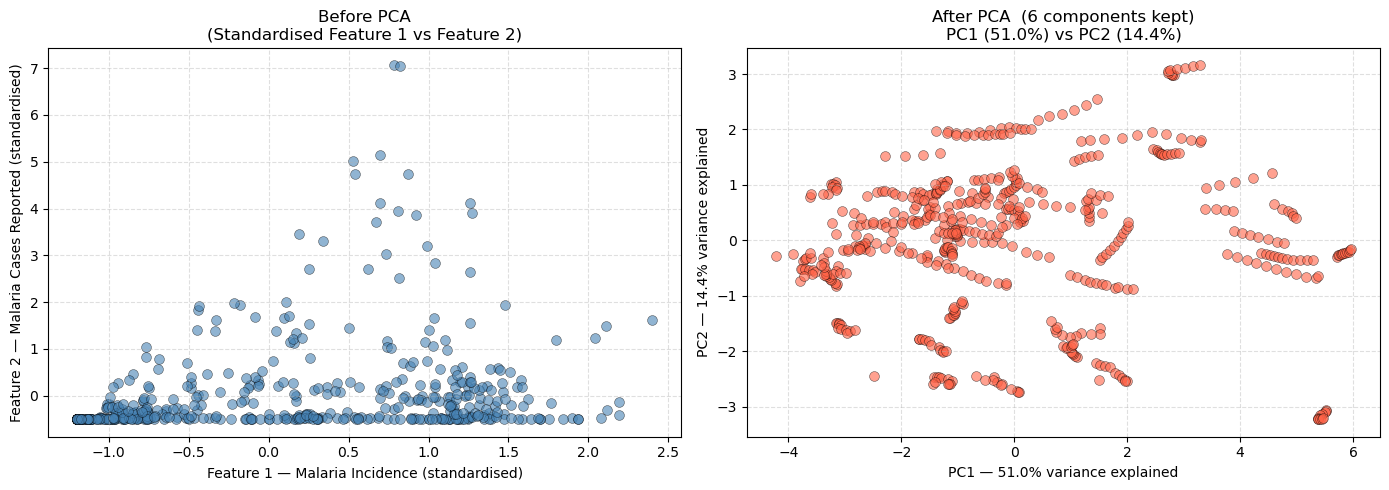

Plot saved as PCA_Before_After.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original data (first two features for simplicity)
axes[0].scatter(
    standardized_data[:, 0], standardized_data[:, 1],
    alpha=0.6, edgecolors='k', linewidths=0.4, color='steelblue', s=50
)
axes[0].set_title("Before PCA\n(Standardised Feature 1 vs Feature 2)", fontsize=12)
axes[0].set_xlabel("Feature 1 — Malaria Incidence (standardised)")
axes[0].set_ylabel("Feature 2 — Malaria Cases Reported (standardised)")
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot reduced data after PCA
axes[1].scatter(
    reduced_data[:, 0], reduced_data[:, 1],
    alpha=0.6, edgecolors='k', linewidths=0.4, color='tomato', s=50
)
axes[1].set_title(
    f"After PCA  ({num_components} components kept)\n"
    f"PC1 ({explained_variance_ratio[0]*100:.1f}%) vs PC2 ({explained_variance_ratio[1]*100:.1f}%)",
    fontsize=12
)
axes[1].set_xlabel(f"PC1 — {explained_variance_ratio[0]*100:.1f}% variance explained")
axes[1].set_ylabel(f"PC2 — {explained_variance_ratio[1]*100:.1f}% variance explained")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("PCA_Before_After.png", dpi=150)
plt.show()
print("Plot saved as PCA_Before_After.png")

## Written Answers

### 1. Interpret the Visual (Before and After PCA) 

The **Before PCA** scatter shows the standardised relationship between malaria incidence and malaria cases reported; most points cluster near the origin with a few extreme outliers along one diagonal, indicating high skew and correlation between these two raw features.
The **After PCA** scatter re-expresses the same 528 observations along the directions of maximum variance: PC1 (~51.0%) spreads the data horizontally, clearly separating low-burden from high-burden countries, while PC2 (~14.4%) captures residual orthogonal variation such as differing intervention coverage levels.
Overall, the PCA plot is cleaner — redundant feature overlap is removed, clusters of African countries with similar malaria profiles become more distinguishable, and high-incidence outliers stand out more clearly on PC1.

---

### 2. Why this number of components, and what tradeoffs are being made? 

**6 principal components** were selected because they are the fewest needed to surpass 90% cumulative explained variance (achieving ~93.4%), balancing information retention against dimensionality reduction.
The primary tradeoff is **compactness vs. completeness**: the 6 dropped components carry ~6.6% of variance — mostly noise or minor feature-specific patterns — which we sacrifice for a lower-dimensional, less computationally expensive representation.
A stricter threshold (e.g. 95%) would require more components and retain more subtle signals; a looser threshold (e.g. 80%) would compress further but risk discarding meaningful country-level variation.
For this malaria dataset, 6 components is a pragmatic choice that preserves dominant health, sanitation, and demographic signals while discarding dimensions that likely represent measurement noise.

---

### 3. What information is lost when reducing dimensions? 

When projecting from 12 to 6 dimensions, the discarded components carry fine-grained independent variation in **economic activity** proxies (e.g. urban population growth rate, safely managed water access — urban vs rural splits) and **population pressure** indicators (e.g. rural population growth, rural sanitation percentages).
Specifically, subtle distinctions between countries that differ mainly in their urban/rural infrastructure gap — rather than overall malaria burden — are collapsed into composite axes or dropped entirely, making it impossible post-reduction to separately interrogate whether a country's malaria risk is driven by urban economic underdevelopment versus rural population overcrowding.
The dropped dimensions also discard country-pair differences that are real but small in magnitude, meaning two countries with distinct rural sanitation trajectories could appear identical in the reduced space.
